In [1]:
from src.ColorsAnalysis import *
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from IPython.display import clear_output
plt.style.use('properties.mplstyle')

In [3]:
results_folder = "../results/ColorAnalysis/3D"
create_folder(results_folder)

Folder already exists: ../results/ColorAnalysis/3D


In [5]:
df_dynamic = pd.read_csv("../SOP_data/all_colors_dynamic.dat", sep=' ')
df_dynamic

,type_perc,dim,L,f_T,c,num_colors,P0,p0,N_samples,rho,nc,nc_err,nc_std,stat_window
0,bond,2,1024,0.001000,0.01,1,0.5,0.8,606,1.00,0.0,0.0,0.0,300
1,bond,2,2048,0.001000,0.01,1,0.5,0.8,306,1.00,0.0,0.0,0.0,300
2,bond,2,4096,0.001000,0.01,1,0.5,0.8,156,1.00,0.0,0.0,0.0,300
3,bond,2,8192,0.001000,0.01,1,0.5,0.8,81,1.00,0.0,0.0,0.0,300
4,bond,2,1024,0.005308,0.01,1,0.5,0.8,404,1.00,0.0,0.0,0.0,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8291,bond,3,1024,0.473737,0.20,4,1.0,0.6,5,0.25,4.0,0.0,0.0,300
8292,bond,3,128,0.500000,0.20,4,1.0,0.6,200,0.25,4.0,0.0,0.0,300
8293,bond,3,256,0.500000,0.20,4,1.0,0.6,150,0.25,4.0,0.0,0.0,300
8294,bond,3,512,0.500000,0.20,4,1.0,0.6,25,0.25,4.0,0.0,0.0,300


In [6]:
df_series = pd.read_csv('../SOP_data/all_data_dynamic.dat', sep=' ')
df_series

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,...,N_samples_perc,p_mean,p_err,f_mean,f_err,z_max_mean,z_max_err,z_stat_mean,z_stat_err,stat_window
0,bond,2,8192,0.022538,0.01,1,1.00,0.8,0.5,0,...,1,0.501080,0.000000,0.022540,0.000000,8192.0,0.0,391.000000,0.000000,300
1,bond,2,8192,0.026846,0.01,1,1.00,0.8,0.5,0,...,2,0.501816,0.000865,0.026897,0.000006,8192.0,0.0,328.000000,12.000000,300
2,bond,2,4096,0.031154,0.01,1,1.00,0.8,0.5,0,...,1,0.501357,0.000000,0.031115,0.000000,4096.0,0.0,294.000000,0.000000,300
3,bond,2,8192,0.031154,0.01,1,1.00,0.8,0.5,0,...,3,0.501402,0.000317,0.031213,0.000025,8192.0,0.0,355.666667,4.666667,300
4,bond,2,4096,0.035462,0.01,1,1.00,0.8,0.5,0,...,4,0.501608,0.000648,0.035541,0.000043,4096.0,0.0,301.000000,12.935739,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18204,bond,3,512,0.500000,0.20,4,0.25,0.6,1.0,3,...,25,1.000000,0.000000,0.250196,0.000191,512.0,0.0,320.000000,0.000000,300
18205,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,0,...,5,1.000000,0.000000,0.250027,0.000210,1024.0,0.0,320.000000,0.000000,300
18206,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,1,...,5,1.000000,0.000000,0.250014,0.000276,1024.0,0.0,320.000000,0.000000,300
18207,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,2,...,5,1.000000,0.000000,0.250026,0.000280,1024.0,0.0,320.000000,0.000000,300


[0.01, 0.03, 0.05, 0.1, 0.15, 0.2]
c = 0.01
ft=0.005146815, L = 128
ft=0.003764543, L = 256
ft=0.005146815, L = 512
ft=0.006529086, L = 1024
==
c = 0.03
ft=0.007911358, L = 128
ft=0.006529086, L = 256
ft=0.007911358, L = 512
ft=0.005146815, L = 1024
==
c = 0.05
ft=0.009293629, L = 128
ft=0.009293629, L = 256
ft=0.009293629, L = 512
ft=0.007911358, L = 1024
==
c = 0.1
ft=0.01344044, L = 128
ft=0.01205817, L = 256
ft=0.01205817, L = 512
ft=0.01344044, L = 1024
==
c = 0.15
ft=0.01344044, L = 128
ft=0.01344044, L = 256
ft=0.01344044, L = 512
ft=0.01482272, L = 1024
==
c = 0.2
ft=0.01482272, L = 128
ft=0.01620499, L = 256
ft=0.01344044, L = 512
ft=0.01482272, L = 1024
==


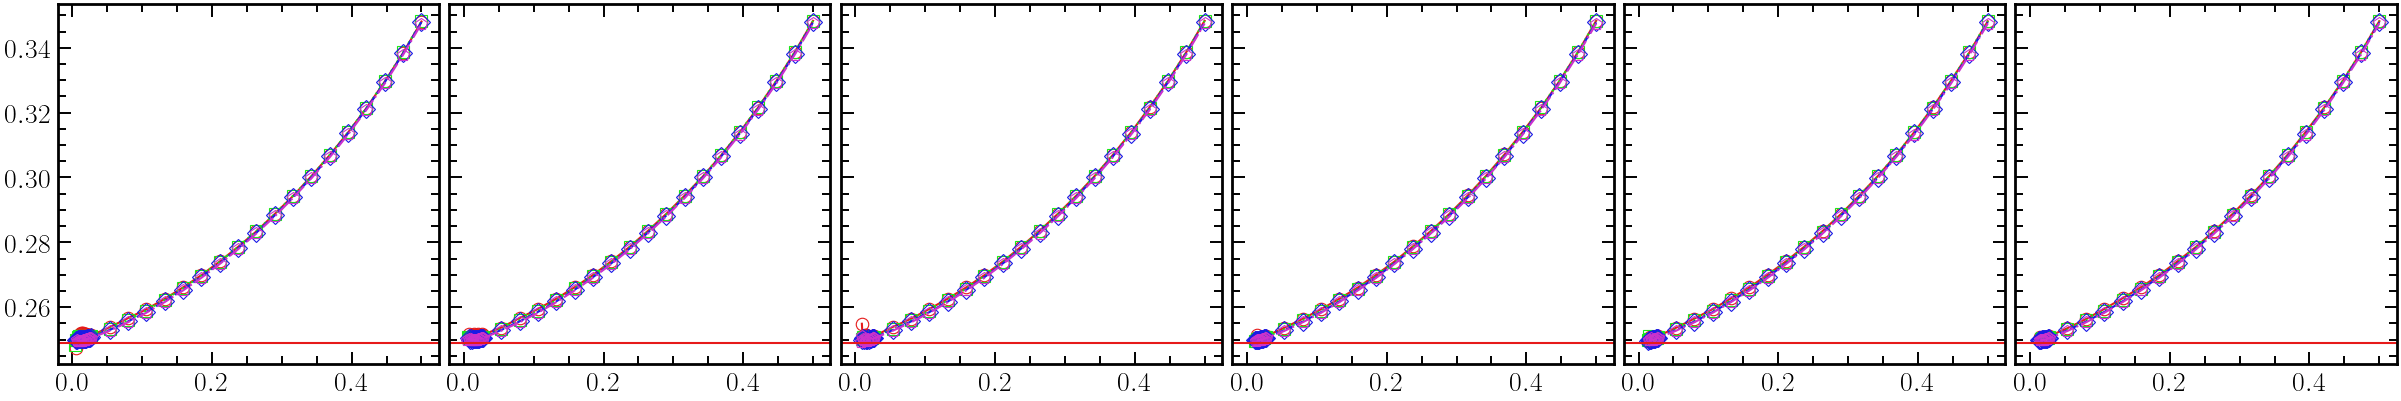

In [11]:

L_lst = [128, 256, 512, 1024]
ns = 1

#c_lst = [0.1, 0.01, 0.15, 0.2, 0.03, 0.05]
c_lst = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2]
print(c_lst)
#c = 0.15
window = 300
base = 4
fig, axes = plt.subplots(1, len(c_lst), figsize=(len(c_lst)*base, base), constrained_layout=True, sharey='row', sharex='row')
markers = ['o', 's', 'D', 'p']
x_min = 0
pc= 0.24881182
for idx, ax in enumerate(axes.flatten()):
    c = c_lst[idx]

    print(f'c = {c}')
    for idx_L, L in enumerate(L_lst):
        df_d = df_series[(df_series['c']==c) & (df_series['nc']==ns) & (df_series['p0']==0.6) & (df_series['dim']==3) & (df_series['L']==L) & (df_series['stat_window']==window)]
        
        df_trunc = df_d[df_d['p_mean']<=0.95]
        
        ft = df_trunc['f_T']
        p = df_trunc['p_mean']
        
        ax.plot(ft, p ,marker=markers[idx_L],label=f'$L= {L}$')
        print(f"ft={min(ft)}, L = {L}")
    print("==")
    ax.axhline(y=pc)
#    ax.set_xlim(xmin, xmax)
# plt.legend()
# plt.xlabel(f'$f_T$')
# plt.ylabel(f'$n_s$')
# plt.title(f'$c={c}$, $n_s={ns}$, dim$=3$')
#plt.xlim(0,0.02)
#plt.savefig("teste.pdf")
plt.show()



In [ ]:
L_lst = [128, 256, 512, 1024]
ns = 3
c_lst = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2]

window = 300
base = 5
dim = 3

tick_fs = 16
label_fs = 18
tick_len = 8
tick_width = 1.4

fs_legend = 15
markers = ['o', 's', 'D', '^']
x_min = 0
ms = 7
mew = 1.4
pc = 0.5
order = 0
rho = round(1/ns, 5)
P0 = 1.0
p0 = 0.6
# ============================================================
# 1) Primeiro calcula ft_min e ft_max comuns para cada c
# ============================================================

ft_bounds = {}

for c in c_lst:
    ft_min_per_L = []
    ft_max_per_L = []

    # ----------------------------
    # ft_min vem da linha 1
    # ----------------------------
    for L in L_lst:
        df_d = df_dynamic[
            (np.isclose(df_dynamic['c'], c)) &
            (df_dynamic['num_colors'] == ns) &
            (df_dynamic['p0'] == p0) &
            (df_dynamic['P0'] == P0) &
            (df_dynamic['dim'] == dim) &
            (df_dynamic['L'] == L) &
            (df_dynamic['stat_window'] == window)
        ]

        ft_valid = df_d.loc[df_d['nc'] == ns, 'f_T'].dropna()

        if ft_valid.empty:
            raise ValueError(
                f"Nenhum ponto encontrado para calcular ft_min: "
                f"c={c}, L={L}, ns={ns}"
            )

        ft_min_per_L.append(ft_valid.min())

    # menor valor comum a todos os L
    ft_min = max(ft_min_per_L)

    # ----------------------------
    # ft_max vem da linha 2
    # depois do truncamento
    # ----------------------------
    for L in L_lst:
        df_s = df_series[
            (np.isclose(df_series['c'], c)) &
            (df_series['nc'] == ns) &
            (df_dynamic['p0'] == p0) &
            (df_dynamic['P0'] == P0) &
            (df_series['dim'] == dim) &
            (df_series['L'] == L) &
            (df_series['stat_window'] == window) &
            (df_series['order'] == order) &
            (np.isclose(df_series['rho'], rho))
        ]

        df_filter = df_s[
            (df_s['f_T'] >= ft_min)
        ]

        df_trunced = df_filter[
            df_filter['p_mean'] <= 0.95
        ].dropna(subset=['f_T', 'p_mean'])

        if df_trunced.empty:
            raise ValueError(
                f"Nenhum ponto encontrado para calcular ft_max: "
                f"c={c}, L={L}, ft_min={ft_min}"
            )

        ft_max_per_L.append(df_trunced['f_T'].max())

    # maior limite superior comum a todos os L
    ft_max = min(ft_max_per_L)

    ft_bounds[c] = {
        'ft_min': ft_min,
        'ft_max': ft_max
    }

    print(f"c={c:.2f} | ft_min={ft_min:.6g} | ft_max={ft_max:.6g}")


# ============================================================
# 2) Agora faz o plot usando os limites calculados
# ============================================================

fig, axes = plt.subplots(
    2, len(c_lst),
    figsize=(14, 6),
    sharey='row'
)

for ax in axes.flat:
    ax.set_box_aspect(1)

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=tick_fs,
        length=tick_len,
        width=tick_width,
        direction='in',
        top=True,
        right=True
    )

    ax.tick_params(
        axis='both',
        which='minor',
        length=5,
        width=1.4,
        direction='in',
        top=True,
        right=True
    )

    ax.minorticks_on()

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.12,
    top=0.92,
    wspace=0.005,
    hspace=0.12
)

# ============================================================
# Linha 1: <nc> versus f_T
# truncada pelo ft_max
# ============================================================

for idx, ax in enumerate(axes[0]):
    c = c_lst[idx]
    ft_min = ft_bounds[c]['ft_min']
    ft_max = ft_bounds[c]['ft_max']

    for idx_L, L in enumerate(L_lst):
        df_d = df_dynamic[
            (np.isclose(df_dynamic['c'], c)) &
            (df_dynamic['num_colors'] == ns) &
            (df_dynamic['p0'] == p0) &
            (df_dynamic['P0'] == P0) &
            (df_dynamic['dim'] == dim) &
            (df_dynamic['L'] == L) &
            (df_dynamic['stat_window'] == window)
        ]

        df_d = df_d[
            df_d['f_T'] <= ft_max
        ]

        ft = df_d['f_T']
        nc_plot = df_d['nc']

        ax.plot(
            ft, nc_plot,
            mew=mew,
            marker=markers[idx_L],
            ms=ms,
            ls='None',
            label=f'$L= {L}$',
            clip_on=False
        )

    ax.set_title(f'$c = {c}$')

    # Linha 1 truncada superiormente por ft_max
    ax.set_xlim(x_min, ft_max)

    if idx == 0:
        ax.set_ylabel(r'$\langle n_c \rangle$', fontsize=label_fs)
        ax.legend(fontsize=fs_legend)


# ============================================================
# Linha 2: p* versus f_T
# truncada por ft_min e ft_max
# ============================================================

for idx, ax in enumerate(axes[1]):
    c = c_lst[idx]
    ft_min = ft_bounds[c]['ft_min']
    ft_max = ft_bounds[c]['ft_max']

    for idx_L, L in enumerate(L_lst):
        df_s = df_series[
            (np.isclose(df_series['c'], c)) &
            (df_series['nc'] == ns) &
            (df_dynamic['p0'] == p0) &
            (df_dynamic['P0'] == P0) &
            (df_series['dim'] == dim) &
            (df_series['L'] == L) &
            (df_series['stat_window'] == window) &
            (df_series['order'] == order) &
            (np.isclose(df_series['rho'], rho))
        ]

        df_filter = df_s[
            (df_s['f_T'] >= ft_min) &
            (df_s['f_T'] <= ft_max)
        ]

        df_trunced = df_filter[
            df_filter['p_mean'] <= 0.95
        ]

        ft = df_trunced['f_T']
        pmean = df_trunced['p_mean']

        ax.plot(
            ft, pmean,
            marker=markers[idx_L],
            mew=mew,
            ms=ms,
            ls='None',
            label=f'$L= {L}$',
            clip_on=False
        )

    ax.axhline(y=pc, color='k', lw=2.0)

    ax.set_xlabel(r'$f_T$', fontsize=label_fs)
    ax.set_xlim(ft_min, ft_max)

    if idx == 0:
        ax.set_ylabel(r'$p^*$', fontsize=label_fs)
        ax.legend(fontsize=fs_legend, loc='upper left')

# plt.savefig(results_folder + "/nc_pmean.pdf", bbox_inches='tight')
plt.show()

ValueError: Nenhum ponto encontrado para calcular ft_max: c=0.01, L=128, ft_min=0.02726316